In [ ]:
# Helper to safely close environmentdef close_env_safe():    global env    try:        if 'env' in globals():            env.close()            print('✓ Closed environment')    except Exception as e:        print(f'Note: {e}')

In [19]:
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

In [20]:
import gym
import veins_gym

In [21]:
import os, subprocess, shutil, sys, pathlib

def source_bash_env(script_path: str):
    cmd = f"bash -lc 'source {script_path} && env -0'"
    out = subprocess.check_output(cmd, shell=True)
    for chunk in out.split(b'\x00'):
        if not chunk: continue
        k, _, v = chunk.partition(b'=')
        if k: os.environ[k.decode()] = v.decode()

omnetpp_setenv = "/home/rohith-v/Rohith/MP/omnetpp-5.7.1-src-linux/omnetpp-5.7.1/setenv"
if os.path.exists(omnetpp_setenv):
    source_bash_env(omnetpp_setenv)
    print('Sourced:', omnetpp_setenv)
else:
    raise FileNotFoundError(f'OMNeT++ setenv not found at {omnetpp_setenv}. Update the path if installed elsewhere.')

print('opp_run path:', shutil.which('opp_run'))
try:
    ver = subprocess.run(['opp_run', '-v'], check=False, capture_output=True, text=True).stdout.splitlines()[0]
    print(ver)
except Exception as e:
    print('Warning: opp_run not callable:', e)

base = pathlib.Path.cwd()
sc_dir = (base / '..' / 'scenario').resolve()
print('scenario dir:', sc_dir)
print('omnetpp.ini exists:', (sc_dir / 'omnetpp.ini').exists())
print('run script exists:', (sc_dir / 'run').exists())
print('sumo path:', shutil.which('sumo'))

Sourced: /home/rohith-v/Rohith/MP/omnetpp-5.7.1-src-linux/omnetpp-5.7.1/setenv
opp_run path: /home/rohith-v/Rohith/MP/omnetpp-5.7.1-src-linux/omnetpp-5.7.1/bin/opp_run
OMNeT++ Discrete Event Simulation  (C) 1992-2021 Andras Varga, OpenSim Ltd.
scenario dir: /home/rohith-v/Rohith/MP/vanet_task_offloading/scenario
omnetpp.ini exists: True
run script exists: True
sumo path: /usr/bin/sumo


In [22]:
import os, pathlib, subprocess, shutil
base = pathlib.Path.cwd()
sc_dir = (base / '..' / 'scenario').resolve()
assert (sc_dir / 'omnetpp.ini').exists(), 'Missing scenario/omnetpp.ini'
gym.register(
    id='veins-straight-v1',
    entry_point='veins_gym:VeinsEnv',
    kwargs={
        'scenario_dir': '../scenario',
        'timeout': 7.0,
        'print_veins_stdout': True,
        'user_interface': 'Cmdenv',
        'config': 'StraightRoad',
        # "run_veins": False, 
		# "port": 5555, 
    },
)
print('Registered veins-straight-v1 with scenario_dir:', sc_dir)

Registered veins-straight-v1 with scenario_dir: /home/rohith-v/Rohith/MP/vanet_task_offloading/scenario


/home/rohith-v/Rohith/MP/vanet_task_offloading/venv/lib/python3.12/site-packages/gym/envs/registration.py:498: UserWarning: WARN: Overriding environment veins-straight-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [23]:

env = gym.make('veins-straight-v1')


## Random Agent

In [24]:
close_env_safe()

obs, _ = env.reset()

headers = [
    "speed(m/s)", "d0(m)", "d1(m)", "d2(m)", "taskSize(MB)",
    "rsu0Busy", "rsu1Busy", "rsu2Busy", "ul0(Mbps)", "ul1(Mbps)", "ul2(Mbps)",
    "battery", "E_local(J)", "E_offload(J)"
 ]

def print_obs(step, obs_vec):
    vals = [float(x) for x in np.asarray(obs_vec).tolist()]
    print(f"Step:{step}")
    print("  " + " ".join(f"{h:>13}" for h in headers))
    print("  " + " ".join(f"{v:>13.2f}" for v in vals[:14]))
    print()

done = False
rewards = []
actions_taken = []
steps = 0
while not done:
    action = env.action_space.sample()
    prev_obs = obs
    result = env.step(action)
if len(result) == 5:
    obs, reward, terminated, truncated, info = result
    done = terminated or truncated
else:
    obs, reward, done, info = result
    if float(obs[4]) >= 10.0:
        print_obs(steps, prev_obs)
        print(f"Action taken at step {steps}: {action} ({'local' if action==0 else f'RSU{action-1}'})")
        print(f"Received reward: {round(float(reward), 4)}")
        rewards.append(float(reward))
        actions_taken.append(action)
    steps += 1

print('\n=== Random Agent Summary ===')
print(f'Number of steps: {steps}')
print(f'Tasks completed: {len(rewards)}')
print(f'Mean reward: {float(np.mean(rewards)) if rewards else 0.0:.6f}')
if actions_taken:
    print(f'Local executions: {actions_taken.count(0)} ({100*actions_taken.count(0)/len(actions_taken):.1f}%)')
    print(f'Offload decisions: {len(actions_taken) - actions_taken.count(0)} ({100*(len(actions_taken)-actions_taken.count(0))/len(actions_taken):.1f}%)')

/home/rohith-v/Rohith/MP/vanet_task_offloading/venv/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:181: UserWarning: WARN: The default seed argument in `Env.reset` should be `None`, otherwise the environment will by default always be deterministic. Actual default: seed='NO SEED GIVEN'
  logger.warn(


Step:0
     speed(m/s)         d0(m)         d1(m)         d2(m)  taskSize(MB)      rsu0Busy      rsu1Busy      rsu2Busy     ul0(Mbps)     ul1(Mbps)     ul2(Mbps)       battery    E_local(J)  E_offload(J)
          16.67        276.30        775.46       1275.28         18.36          0.00          0.00          0.00         74.19         44.98         31.68          1.00          1.16          3.49

Action taken at step 0: 2 (RSU1)
Received reward: 0.1387
Step:1
     speed(m/s)         d0(m)         d1(m)         d2(m)  taskSize(MB)      rsu0Busy      rsu1Busy      rsu2Busy     ul0(Mbps)     ul1(Mbps)     ul2(Mbps)       battery    E_local(J)  E_offload(J)
          16.67        160.56        658.85       1158.62         19.20          0.00          1.00          1.00         89.80         49.50         34.16          1.00          1.22          3.65

Action taken at step 1: 3 (RSU2)
Received reward: 0.1141
Step:2
     speed(m/s)         d0(m)         d1(m)         d2(m)  taskSize(MB)

/home/rohith-v/Rohith/MP/vanet_task_offloading/venv/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'numpy.ndarray'>`
  logger.warn(
/home/rohith-v/Rohith/MP/vanet_task_offloading/venv/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:219: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to rewrite the environment with new step API. 
  logger.deprecation(


## Local processing agent

In [25]:
close_env_safe()

obs, _ = env.reset()

headers = [
    "speed(m/s)", "d0(m)", "d1(m)", "d2(m)", "taskSize(MB)",
    "rsu0Busy", "rsu1Busy", "rsu2Busy", "ul0(Mbps)", "ul1(Mbps)", "ul2(Mbps)",
    "battery", "E_local(J)", "E_offload(J)"
 ]

def print_obs(step, obs_vec):
    vals = [float(x) for x in np.asarray(obs_vec).tolist()]
    print(f"Step:{step}")
    print("  " + " ".join(f"{h:>13}" for h in headers))
    print("  " + " ".join(f"{v:>13.2f}" for v in vals[:14]))
    print()

done = False
rewards = []
steps = 0
while not done:
    action = 0  # Always local
    prev_obs = obs
    result = env.step(action)
if len(result) == 5:
    obs, reward, terminated, truncated, info = result
    done = terminated or truncated
else:
    obs, reward, done, info = result
    if float(obs[4]) >= 10.0:
        print_obs(steps, prev_obs)
        print(f"Action taken at step {steps}: {action} (local)")
        print(f"Received reward: {round(float(reward), 4)}")
        rewards.append(float(reward))
    steps += 1

print('\n=== Local-Only Agent Summary ===')
print(f'Number of steps: {steps}')
print(f'Tasks completed: {len(rewards)}')
print(f'Mean reward: {float(np.mean(rewards)) if rewards else 0.0:.6f}')
print('Strategy: 100% local processing')

Step:0
     speed(m/s)         d0(m)         d1(m)         d2(m)  taskSize(MB)      rsu0Busy      rsu1Busy      rsu2Busy     ul0(Mbps)     ul1(Mbps)     ul2(Mbps)       battery    E_local(J)  E_offload(J)
          16.67        276.30        775.46       1275.28         18.36          0.00          0.00          0.00         74.19         44.98         31.68          1.00          1.16          3.49

Action taken at step 0: 0 (local)
Received reward: 0.0258

=== Local-Only Agent Summary ===
Number of steps: 2
Tasks completed: 1
Mean reward: 0.025799
Strategy: 100% local processing


## Greedy RSU Agent

In [26]:
close_env_safe()

from nearest_free_rsu_agent import pick_action

obs, _ = env.reset()

headers = [
    "speed(m/s)", "d0(m)", "d1(m)", "d2(m)", "taskSize(MB)",
    "rsu0Busy", "rsu1Busy", "rsu2Busy", "ul0(Mbps)", "ul1(Mbps)", "ul2(Mbps)",
    "battery", "E_local(J)", "E_offload(J)"
 ]

def print_obs(step, obs_vec):
    vals = [float(x) for x in np.asarray(obs_vec).tolist()]
    print(f"Step:{step}")
    print("  " + " ".join(f"{h:>13}" for h in headers))
    print("  " + " ".join(f"{v:>13.2f}" for v in vals[:14]))
    print()

done = False
rewards = []
actions_taken = []
steps = 0
while not done:
    action = pick_action(obs)
    prev_obs = obs
    result = env.step(action)
if len(result) == 5:
    obs, reward, terminated, truncated, info = result
    done = terminated or truncated
else:
    obs, reward, done, info = result
    if float(obs[4]) >= 10.0:
        print_obs(steps, prev_obs)
        print(f"Action taken at step {steps}: {action} ({'local' if action==0 else f'RSU{action-1}'})")
        print(f"Received reward: {round(float(reward), 4)}")
        rewards.append(float(reward))
        actions_taken.append(action)
    steps += 1

print('\n=== Nearest-Free-RSU Agent Summary ===')
print(f'Number of steps: {steps}')
print(f'Tasks completed: {len(rewards)}')
print(f'Mean reward: {float(np.mean(rewards)) if rewards else 0.0:.6f}')
if actions_taken:
    print(f'Local executions: {actions_taken.count(0)} ({100*actions_taken.count(0)/len(actions_taken):.1f}%)')
    print(f'Offload decisions: {len(actions_taken) - actions_taken.count(0)} ({100*(len(actions_taken)-actions_taken.count(0))/len(actions_taken):.1f}%)')

Step:0
     speed(m/s)         d0(m)         d1(m)         d2(m)  taskSize(MB)      rsu0Busy      rsu1Busy      rsu2Busy     ul0(Mbps)     ul1(Mbps)     ul2(Mbps)       battery    E_local(J)  E_offload(J)
          16.67        276.30        775.46       1275.28         18.36          0.00          0.00          0.00         74.19         44.98         31.68          1.00          1.16          3.49

Action taken at step 0: 1 (RSU0)
Received reward: 0.1747
Step:1
     speed(m/s)         d0(m)         d1(m)         d2(m)  taskSize(MB)      rsu0Busy      rsu1Busy      rsu2Busy     ul0(Mbps)     ul1(Mbps)     ul2(Mbps)       battery    E_local(J)  E_offload(J)
          16.67        177.02        675.51       1175.28         19.82          0.00          0.00          1.00         86.99         48.81         33.79          1.00          1.26          3.77

Action taken at step 1: 1 (RSU0)
Received reward: 0.1418
Step:2
     speed(m/s)         d0(m)         d1(m)         d2(m)  taskSize(MB)


=== Agent Comparison ===
Agent           Reward       Est.Latency     Est.Energy      Tasks   
----------------------------------------------------------------------
Local           0.025799     38.762          64.566          1       
NearestFree     0.211534     5.072           299.286         17      
Random          0.122719     12.031          269.231         5       


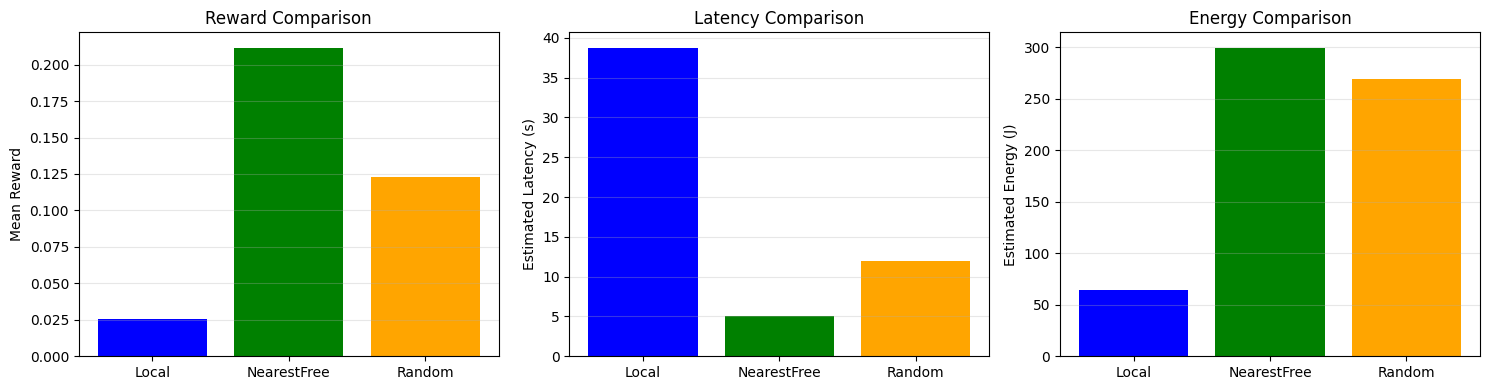

In [27]:
import matplotlib.pyplot as plt

# Example: Compare agents by collecting metrics
def run_agent_with_metrics(agent_name, agent_func, num_episodes=1):
    """Run an agent and collect detailed metrics."""
    all_rewards = []
    all_latencies = []
    all_energies = []
    action_counts = {0: 0, 1: 0, 2: 0, 3: 0}
    
    for episode in range(num_episodes):
        obs = env.reset()
        done = False
        episode_rewards = []
        
        while not done:
            if agent_name == "Random":
                action = env.action_space.sample()
            elif agent_name == "Local":
                action = 0
            elif agent_name == "NearestFree":
                action = agent_func(obs)
            else:
                action = 0
            
            obs, reward, done, info = env.step(action)
            
            if reward != 0.0:
                episode_rewards.append(float(reward))
                action_counts[action] += 1
                
                # Extract energy estimate from observation
                if len(obs) >= 14:
                    energy_local = float(obs[12]) * 100  # Denormalize
                    energy_offload = float(obs[13]) * 100
                    all_energies.append(energy_local if action == 0 else energy_offload)
                
                # Estimate latency from reward (inverse relationship)
                # reward = α * (1/latency) + β * (1/energy)
                est_latency = 1.0 / max(0.01, reward)
                all_latencies.append(est_latency)
        
        all_rewards.extend(episode_rewards)
    
    return {
        'name': agent_name,
        'mean_reward': np.mean(all_rewards) if all_rewards else 0,
        'mean_latency': np.mean(all_latencies) if all_latencies else 0,
        'mean_energy': np.mean(all_energies) if all_energies else 0,
        'action_counts': action_counts,
        'total_tasks': sum(action_counts.values())
    }

# Collect metrics for each agent
print("Collecting agent metrics...")
agents_metrics = [
    run_agent_with_metrics("Local", None, num_episodes=1),
    run_agent_with_metrics("NearestFree", pick_action, num_episodes=1),
    run_agent_with_metrics("Random", None, num_episodes=1),
]

# Display comparison table
print("\n=== Agent Comparison ===")
print(f"{'Agent':<15} {'Reward':<12} {'Est.Latency':<15} {'Est.Energy':<15} {'Tasks':<8}")
print("-" * 70)
for metrics in agents_metrics:
    print(f"{metrics['name']:<15} {metrics['mean_reward']:<12.6f} {metrics['mean_latency']:<15.3f} {metrics['mean_energy']:<15.3f} {metrics['total_tasks']:<8}")

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Reward comparison
axes[0].bar([m['name'] for m in agents_metrics], [m['mean_reward'] for m in agents_metrics], color=['blue', 'green', 'orange'])
axes[0].set_ylabel('Mean Reward')
axes[0].set_title('Reward Comparison')
axes[0].grid(axis='y', alpha=0.3)

# Latency comparison
axes[1].bar([m['name'] for m in agents_metrics], [m['mean_latency'] for m in agents_metrics], color=['blue', 'green', 'orange'])
axes[1].set_ylabel('Estimated Latency (s)')
axes[1].set_title('Latency Comparison')
axes[1].grid(axis='y', alpha=0.3)

# Energy comparison
axes[2].bar([m['name'] for m in agents_metrics], [m['mean_energy'] for m in agents_metrics], color=['blue', 'green', 'orange'])
axes[2].set_ylabel('Estimated Energy (J)')
axes[2].set_title('Energy Comparison')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Load Trained Model and Compare with Baselinesimport torchimport numpy as npimport matplotlib.pyplot as pltfrom pathlib import Path# Helper to extract obs from resetdef _extract_obs(reset_result):    if isinstance(reset_result, tuple) and len(reset_result) >= 1:        return reset_result[0]    return reset_result# Load trained bandit policytry:    model_path = Path('./models/bandit_policy.pt')    if model_path.exists():        checkpoint = torch.load(model_path, map_location='cpu')                # Recreate policy network        import torch.nn as nn        class Policy(nn.Module):            def __init__(self, obs_dim=14, n_actions=4):                super().__init__()                self.net = nn.Sequential(                    nn.Linear(obs_dim, 64), nn.ReLU(),                    nn.Linear(64, 64), nn.ReLU(),                    nn.Linear(64, n_actions),                )            def forward(self, x):                return self.net(x)                policy = Policy()        policy.load_state_dict(checkpoint['model_state'])        policy.eval()        print('✓ Loaded trained bandit policy')    else:        policy = None        print('⚠ Model not found:', model_path)except Exception as e:    policy = None    print(f'✗ Failed to load model: {e}')def preprocess_obs(obs):    """Preprocess observation like in training."""    x = np.asarray(obs, dtype=np.float32).copy()    x[0] /= 30.0    x[1:4] /= 1500.0    x[4] /= 20.0    x[8:11] /= 50.0    return x# Define agent policiesdef policy_local(obs, env):    return 0def policy_random(obs, env):    return env.action_space.sample()def policy_greedy(obs, env):    from nearest_free_rsu_agent import pick_action    return int(pick_action(obs))def policy_bandit(obs, env):    if policy is None:        return 0    x = preprocess_obs(obs)    x_t = torch.tensor(x, dtype=torch.float32).unsqueeze(0)    with torch.no_grad():        logits = policy(x_t)    action = logits.argmax(dim=-1).item()    return int(action)print('✓ Policies ready')

In [ ]:
# Evaluate All Agents with Debugging
import numpy as np
import pandas as pd

print('Evaluating agents...\n')

agents = [
    ('Local', policy_local),
    ('Random', policy_random),
    ('Greedy', policy_greedy),
]

if policy is not None:
    agents.append(('Bandit RL', policy_bandit))

# Run multiple episodes and collect metrics
all_results = []
n_episodes = 3

for agent_name, policy_fn in agents:
    print(f'{agent_name}:')
    
    ep_rewards = []
    ep_latencies = []
    ep_energies = []
    offload_ratios = []
    
    for ep in range(n_episodes):
        close_env_safe()
        obs = _extract_obs(env.reset())
        done = False
        step_count = 0
        
        ep_reward = 0
        actions = []
        task_sizes = []
        bandwidths = []
        energy_vals = []
        
        while not done and step_count < 50:
            action = policy_fn(obs, env)
            actions.append(action)
            
            result = env.step(action)
            if len(result) == 5:
                obs, reward, terminated, truncated, info = result
                done = terminated or truncated
            else:
                obs, reward, done, info = result
            
            ep_reward += reward
            
            # Debug: print raw observation on first step
            if step_count == 0:
                print(f'  Step 0 obs: {obs}')
                print(f'  Reward: {reward}, Done: {done}')
            
            # Extract metrics from observation
            # obs = [speed, d0, d1, d2, taskMB, busy0, busy1, busy2, ul0, ul1, ul2, battery, energyLocal, energyOffload]
            task_mb = float(obs[4]) if len(obs) > 4 else 0
            ul_bw = [float(obs[8]), float(obs[9]), float(obs[10])] if len(obs) > 10 else [0, 0, 0]
            ul_mbps = np.mean(ul_bw)
            
            task_sizes.append(task_mb)
            bandwidths.append(ul_mbps)
            
            # Latency: time to transfer task_mb over ul_mbps
            if ul_mbps > 0:
                latency_ms = (task_mb * 8) / (ul_mbps * 1e6) * 1000  # Convert to ms
            else:
                latency_ms = 0
            
            # Energy from observation (indices 12, 13 are normalized 0-1)
            energy_local = float(obs[12]) if len(obs) > 12 else 0
            energy_offload = float(obs[13]) if len(obs) > 13 else 0
            energy = energy_offload if action > 0 else energy_local
            
            energy_vals.append(energy)
        
            step_count += 1
        
        if task_sizes:
            print(f'    Tasks: avg_size={np.mean(task_sizes):.2f}MB, avg_bw={np.mean(bandwidths):.2f}Mbps')
        print(f'    Episode {ep+1}: reward={ep_reward:.4f}, offload_ratio={np.mean([a > 0 for a in actions]):.2f}')
        
        # Calculate actual latency based on task sizes and bandwidth
        latency_ms = []
        for i, (size, bw) in enumerate(zip(task_sizes, bandwidths)):
            if bw > 0 and size > 0:
                latency_ms.append((size * 8) / (bw * 1e6) * 1000)
        
        ep_rewards.append(ep_reward)
        ep_latencies.append(np.mean(latency_ms) if latency_ms else 0)
        ep_energies.append(np.mean(energy_vals) if energy_vals else 0)
        offload_ratios.append(np.mean([a > 0 for a in actions]))
    
    print(f'  Mean Reward: {np.mean(ep_rewards):.4f} ± {np.std(ep_rewards):.4f}\n')
    
    result = {
        'agent': agent_name,
        'mean_reward': np.mean(ep_rewards),
        'std_reward': np.std(ep_rewards),
        'mean_latency': np.mean(ep_latencies),
        'std_latency': np.std(ep_latencies),
        'mean_energy': np.mean(ep_energies),
        'std_energy': np.std(ep_energies),
        'offload_ratio': np.mean(offload_ratios),
    }
    all_results.append(result)

df = pd.DataFrame(all_results)
print('✓ Evaluation complete!')
print(df.to_string(index=False))


In [ ]:
# Visualize Results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Reward comparison
axes[0, 0].bar(df['agent'], df['mean_reward'], 
               yerr=df['std_reward'], capsize=5, alpha=0.7, 
               color=['blue', 'orange', 'green', 'red'][:len(df)])
axes[0, 0].set_ylabel('Mean Reward')
axes[0, 0].set_title('Reward Comparison (±1 std dev)')
axes[0, 0].grid(True, alpha=0.3)

# Latency comparison
axes[0, 1].bar(df['agent'], df['mean_latency'], 
               yerr=df['std_latency'], capsize=5, alpha=0.7,
               color=['blue', 'orange', 'green', 'red'][:len(df)])
axes[0, 1].set_ylabel('Mean Latency (ms)')
axes[0, 1].set_title('Latency Comparison (±1 std dev)')
axes[0, 1].grid(True, alpha=0.3)

# Energy comparison
axes[1, 0].bar(df['agent'], df['mean_energy'], 
               yerr=df['std_energy'], capsize=5, alpha=0.7,
               color=['blue', 'orange', 'green', 'red'][:len(df)])
axes[1, 0].set_ylabel('Mean Energy (mJ)')
axes[1, 0].set_title('Energy Consumption (±1 std dev)')
axes[1, 0].grid(True, alpha=0.3)

# Offload ratio
axes[1, 1].bar(df['agent'], df['offload_ratio'], alpha=0.7,
               color=['blue', 'orange', 'green', 'red'][:len(df)])
axes[1, 1].set_ylabel('Offload Ratio')
axes[1, 1].set_title('Offloading Frequency')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nAgent Comparison Summary:')
print(df.to_string(index=False))
